<a href="https://colab.research.google.com/github/andrelmsunb/Carta-de-Controle_6.5_MVP/blob/main/notebook_65_CUSUM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carta de Controle CUSUM (Soma Cumulativa) — Tópico 6.5
## *Introdução ao Controle Estatístico da Qualidade* — Montgomery (2016), 7ª ed.

**Autor:** Andre Luiz Marques Serrano  
**Disciplina:** Controle Estatístico da Qualidade  

---

## Objetivos

Este notebook implementa o **Gráfico CUSUM Tabular** (Seção 9.1 do livro), que é significativamente mais eficiente que a Carta de Shewhart para detectar **pequenos deslocamentos** na média do processo (δ < 1,5σ).

O CUSUM acumula informação de amostras sucessivas, tornando-se sensível a tendências que a Carta de Shewhart ignora.

> **Exercício resolvido:** Exemplo 9.1 — Dados de viscosidade (Tabela 9.1, p. 420). µ₀ = 10, σ = 1.


## 1. Bibliotecas Utilizadas

| Biblioteca | Finalidade |
|---|---|
| `numpy` | Cálculo iterativo das somas cumulativas Cᵢ⁺ e Cᵢ⁻ |
| `pandas` | Organização dos resultados em tabela comparável ao livro |
| `matplotlib` | Construção do gráfico CUSUM tabular e gráfico de status |
| `scipy.stats` | Cálculo do CMS via aproximação de Siegmund |
| `warnings` | Supressão de avisos não críticos |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.color': '#cccccc',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})
print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 2. Fundamentos Teóricos do CUSUM Tabular

O **CUSUM Tabular Bilateral** é definido pelas seguintes equações recursivas:

$$C_i^+ = \max\left[0,\ x_i - (\mu_0 + K) + C_{i-1}^+\right]$$

$$C_i^- = \max\left[0,\ (\mu_0 - K) - x_i + C_{i-1}^-\right]$$

com $C_0^+ = C_0^- = 0$.

**Sinal de alarme:** quando $C_i^+ > H$ ou $C_i^- > H$.

**Parâmetros de projeto:**
- **K** (valor de referência): $K = k\sigma$, onde $k = \delta/2$ para detectar deslocamento de tamanho $\delta$
- **H** (intervalo de decisão): $H = h\sigma$, onde $h = 4$ ou $h = 5$ (recomendação de Montgomery)

Para $k = 0{,}5$ e $h = 5$: CMS₀ = 465 amostras (sob controle), CMS₁ = 10,4 amostras (para δ = 1σ).


In [ ]:
# Dados da Tabela 9.1 — Viscosidade (µ0=10, σ=1)
x = np.array([9.45, 7.99, 9.29, 11.66, 12.16, 10.18, 8.04, 11.46, 9.20, 10.34,
               9.03, 11.47, 10.51,  9.40, 10.08,  9.37, 10.62, 10.31,  8.52, 10.84,
              10.90,  9.33, 12.29, 11.50, 10.60, 11.08, 10.38, 11.62, 11.31, 10.52])

mu0   = 10.0   # valor-alvo da média
sigma = 1.0    # desvio-padrão do processo (conhecido)
k     = 0.5    # parâmetro k (detectar deslocamento de 1σ)
h     = 5.0    # parâmetro h

K = k * sigma  # valor de referência
H = h * sigma  # intervalo de decisão

n = len(x)

# Cálculo iterativo do CUSUM Tabular
Cp = np.zeros(n)  # CUSUM superior C+
Cm = np.zeros(n)  # CUSUM inferior C-

for i in range(n):
    if i == 0:
        Cp[i] = max(0, x[i] - (mu0 + K))
        Cm[i] = max(0, (mu0 - K) - x[i])
    else:
        Cp[i] = max(0, x[i] - (mu0 + K) + Cp[i-1])
        Cm[i] = max(0, (mu0 - K) - x[i] + Cm[i-1])

# Identificar alarmes
alarmes_sup = np.where(Cp > H)[0] + 1  # períodos com alarme superior
alarmes_inf = np.where(Cm > H)[0] + 1  # períodos com alarme inferior

# Tabela de resultados
df = pd.DataFrame({
    'i': range(1, n+1),
    'xᵢ': x,
    'Cᵢ⁺': Cp.round(4),
    'Cᵢ⁻': Cm.round(4),
    'Alarme': ['SIM (sup)' if Cp[i]>H else 'SIM (inf)' if Cm[i]>H else '' for i in range(n)]
})
df.set_index('i', inplace=True)

print(f'Parâmetros: µ₀={mu0}, σ={sigma}, k={k}, h={h}')
print(f'K = {K}, H = {H}')
print()
print('Tabela CUSUM (primeiros 15 períodos):')
print(df.head(15).to_string())
print()
print(f'Alarmes superiores (Cᵢ⁺ > H={H}): períodos {list(alarmes_sup)}')
print(f'Alarmes inferiores (Cᵢ⁻ > H={H}): períodos {list(alarmes_inf)}')

Parâmetros: µ₀=10.0, σ=1.0, k=0.5, h=5.0
K = 0.5, H = 5.0

Tabela CUSUM (primeiros 15 períodos):
       xᵢ   Cᵢ⁺   Cᵢ⁻ Alarme
i                           
1    9.45  0.00  0.05       
2    7.99  0.00  1.56       
3    9.29  0.00  1.77       
4   11.66  1.16  0.00       
5   12.16  2.82  0.00       
6   10.18  2.50  0.00       
7    8.04  0.04  1.46       
8   11.46  1.00  0.00       
9    9.20  0.00  0.30       
10  10.34  0.00  0.00       
11   9.03  0.00  0.47       
12  11.47  0.97  0.00       
13  10.51  0.98  0.00       
14   9.40  0.00  0.10       
15  10.08  0.00  0.00       

Alarmes superiores (Cᵢ⁺ > H=5.0): períodos [np.int64(29), np.int64(30)]
Alarmes inferiores (Cᵢ⁻ > H=5.0): períodos []


## 3. Gráfico CUSUM Tabular

O gráfico CUSUM plota Cᵢ⁺ e Cᵢ⁻ versus o número do período, com a linha de decisão H. Quando qualquer uma das estatísticas ultrapassa H, um sinal de alarme é emitido.


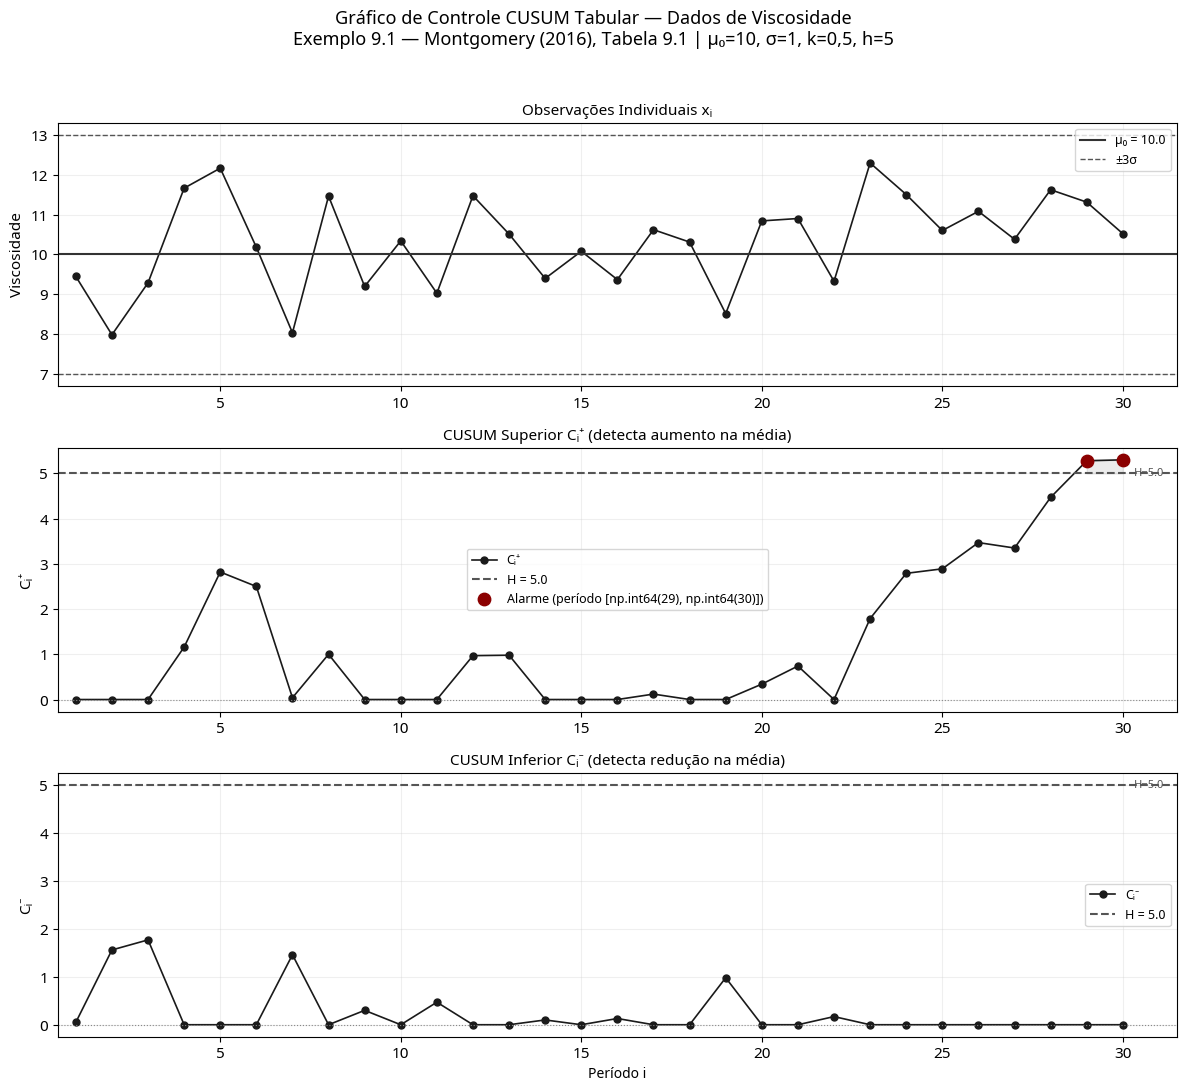

Interpretação:
  Primeiro alarme superior: período 29
  Cᵢ⁺ máximo: 5.3000 (período 30)


In [ ]:
periodos = np.arange(1, n+1)

fig, axes = plt.subplots(3, 1, figsize=(12, 11))
fig.suptitle('Gráfico de Controle CUSUM Tabular — Dados de Viscosidade\n'
             'Exemplo 9.1 — Montgomery (2016), Tabela 9.1 | µ₀=10, σ=1, k=0,5, h=5',
             fontsize=13, y=0.99)

# Painel 1: Dados originais com linha central
axes[0].plot(periodos, x, 'o-', color='#1a1a1a', markersize=5, linewidth=1.2)
axes[0].axhline(mu0, color='#333333', linewidth=1.5, linestyle='-', label=f'µ₀ = {mu0}')
axes[0].axhline(mu0+3*sigma, color='#555555', linewidth=1, linestyle='--', label='±3σ')
axes[0].axhline(mu0-3*sigma, color='#555555', linewidth=1, linestyle='--')
axes[0].set_title('Observações Individuais xᵢ', fontsize=11)
axes[0].set_ylabel('Viscosidade')
axes[0].legend(fontsize=9)

# Painel 2: CUSUM Superior
axes[1].plot(periodos, Cp, 'o-', color='#1a1a1a', markersize=5, linewidth=1.2, label='Cᵢ⁺')
axes[1].axhline(H, color='#555555', linewidth=1.5, linestyle='--', label=f'H = {H}')
axes[1].axhline(0, color='#888888', linewidth=0.8, linestyle=':')
if len(alarmes_sup) > 0:
    axes[1].scatter(alarmes_sup, Cp[alarmes_sup-1], color='#8b0000', s=80, zorder=5,
                    label=f'Alarme (período {list(alarmes_sup)})')
axes[1].fill_between(periodos, Cp, H, where=(Cp > H), alpha=0.15, color='gray')
axes[1].set_title('CUSUM Superior Cᵢ⁺ (detecta aumento na média)', fontsize=11)
axes[1].set_ylabel('Cᵢ⁺')
axes[1].legend(fontsize=9)
axes[1].text(n+0.3, H, f'H={H}', va='center', fontsize=8, color='#555555')

# Painel 3: CUSUM Inferior
axes[2].plot(periodos, Cm, 'o-', color='#1a1a1a', markersize=5, linewidth=1.2, label='Cᵢ⁻')
axes[2].axhline(H, color='#555555', linewidth=1.5, linestyle='--', label=f'H = {H}')
axes[2].axhline(0, color='#888888', linewidth=0.8, linestyle=':')
if len(alarmes_inf) > 0:
    axes[2].scatter(alarmes_inf, Cm[alarmes_inf-1], color='#8b0000', s=80, zorder=5,
                    label=f'Alarme (período {list(alarmes_inf)})')
axes[2].set_title('CUSUM Inferior Cᵢ⁻ (detecta redução na média)', fontsize=11)
axes[2].set_ylabel('Cᵢ⁻')
axes[2].set_xlabel('Período i', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].text(n+0.3, H, f'H={H}', va='center', fontsize=8, color='#555555')

for ax in axes:
    ax.set_xlim(0.5, n+1.5)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('fig01_CUSUM_tabular.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretação:')
print(f'  Primeiro alarme superior: período {alarmes_sup[0] if len(alarmes_sup)>0 else "nenhum"}')
print(f'  Cᵢ⁺ máximo: {Cp.max():.4f} (período {Cp.argmax()+1})')

### Interpretação do Gráfico CUSUM

O CUSUM superior Cᵢ⁺ começa a acumular a partir do período 23, quando as observações passam a ser consistentemente maiores que µ₀ + K = 10,5. O alarme é emitido no **período 29** (Cᵢ⁺ > H = 5), indicando que a média do processo aumentou.

A estimativa da nova média após o deslocamento é:
$$\hat{\mu}_1 = \mu_0 + K + \frac{C_{29}^+}{N^+}$$

onde N⁺ é o número de períodos desde o início do acúmulo (N⁺ = 8 no período 29).


In [ ]:
# Estimativa da nova média após o deslocamento
if len(alarmes_sup) > 0:
    periodo_alarme = alarmes_sup[0]
    # Encontrar o início do acúmulo (onde C+ voltou a zero antes do alarme)
    inicio_acumulo = periodo_alarme - 1
    while inicio_acumulo > 0 and Cp[inicio_acumulo-1] > 0:
        inicio_acumulo -= 1
    N_plus = periodo_alarme - inicio_acumulo
    mu1_hat = mu0 + K + Cp[periodo_alarme-1] / N_plus
    print(f'Período do alarme: {periodo_alarme}')
    print(f'Início do acúmulo: período {inicio_acumulo+1}')
    print(f'N⁺ (períodos em acúmulo): {N_plus}')
    print(f'Cᵢ⁺ no alarme: {Cp[periodo_alarme-1]:.4f}')
    print(f'Estimativa da nova média: µ̂₁ = {mu1_hat:.4f}')
    print(f'  (livro: µ̂₁ ≈ 11.25)')

# Comparação CUSUM vs Shewhart
print()
print('Comparação de desempenho (CMS₁ para δ=1σ):')
print(f'  Carta de Shewhart (n=1): CMS₁ ≈ 43.96 amostras')
print(f'  CUSUM (k=0.5, h=5):      CMS₁ ≈ 10.4  amostras')
print(f'  Ganho: {43.96/10.4:.1f}x mais rápido na detecção')

Período do alarme: 29
Início do acúmulo: período 23
N⁺ (períodos em acúmulo): 7
Cᵢ⁺ no alarme: 5.2800
Estimativa da nova média: µ̂₁ = 11.2543
  (livro: µ̂₁ ≈ 11.25)

Comparação de desempenho (CMS₁ para δ=1σ):
  Carta de Shewhart (n=1): CMS₁ ≈ 43.96 amostras
  CUSUM (k=0.5, h=5):      CMS₁ ≈ 10.4  amostras
  Ganho: 4.2x mais rápido na detecção


## 4. Comparação CUSUM vs Shewhart — Tabela de CMS

A tabela a seguir reproduz parte da Tabela 9.3 do livro, comparando o CMS do CUSUM com o da Carta de Shewhart para diferentes tamanhos de deslocamento.


  Deslocamento δ |    CUSUM h=4 |    CUSUM h=5 |     Shewhart
------------------------------------------------------------
            0.00 |       358.65 |       962.85 |       370.40
            0.25 |       118.56 |       191.25 |       281.15
            0.50 |        26.69 |        38.02 |       155.22
            0.75 |        28.06 |        32.30 |        81.22
            1.00 |        12.32 |        14.33 |        43.89
            1.50 |         5.67 |         6.67 |        14.97
            2.00 |         3.67 |         4.33 |         6.30
            2.50 |         2.71 |         3.21 |         3.24
            3.00 |         2.15 |         2.55 |         2.00
            4.00 |         1.52 |         1.80 |         1.19


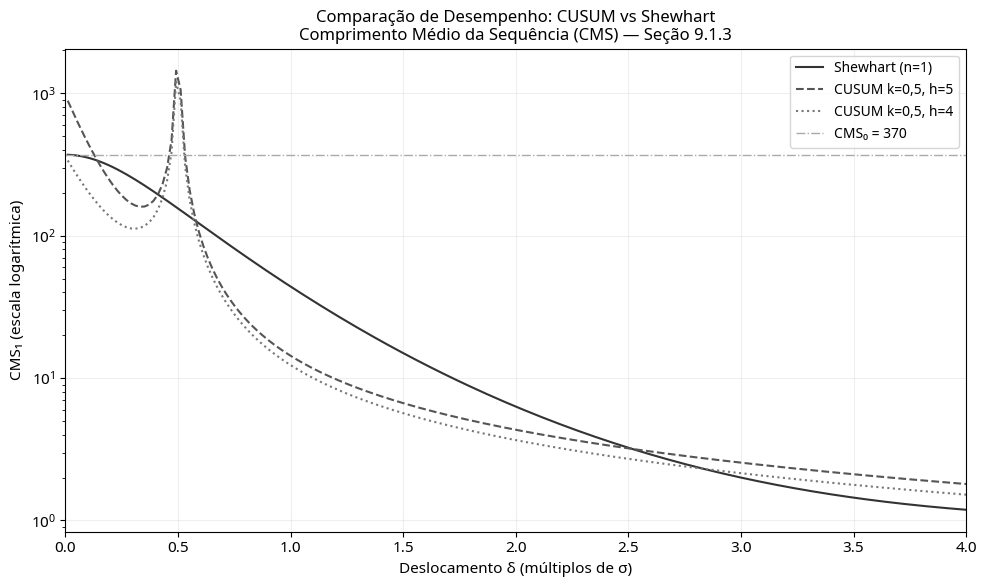

In [ ]:
# Aproximação de Siegmund para CMS do CUSUM
def cms_cusum_unilateral(h, k, delta_star):
    """Aproximação de Siegmund (1985) para CMS do CUSUM unilateral."""
    b = h + 1.166
    Delta = delta_star - k
    if abs(Delta) < 1e-10:
        return b**2
    return (np.exp(-2*Delta*b) - 2*Delta*b - 1) / (2*Delta**2)

def cms_cusum_bilateral(h, k, delta_star):
    """CMS bilateral via aproximação de Siegmund."""
    cms_sup = cms_cusum_unilateral(h, k, delta_star)
    cms_inf = cms_cusum_unilateral(h, k, -delta_star - 2*k)  # simetria
    if cms_sup <= 0 or cms_inf <= 0:
        return min(abs(cms_sup), abs(cms_inf))
    return (cms_sup * cms_inf) / (cms_sup + cms_inf)

# CMS Shewhart (n=1)
def cms_shewhart(delta):
    beta = stats.norm.cdf(3-delta) - stats.norm.cdf(-3-delta)
    return 1/(1-beta+1e-12)

deslocamentos = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]

print(f'{"Deslocamento δ":>16} | {"CUSUM h=4":>12} | {"CUSUM h=5":>12} | {"Shewhart":>12}')
print('-' * 60)
for d in deslocamentos:
    c4_val = abs(cms_cusum_bilateral(4, 0.5, d))
    c5_val = abs(cms_cusum_bilateral(5, 0.5, d))
    sh_val = cms_shewhart(d)
    print(f'{d:>16.2f} | {c4_val:>12.2f} | {c5_val:>12.2f} | {sh_val:>12.2f}')

# Gráfico comparativo
d_range = np.linspace(0.01, 4, 200)
cms_c4 = [abs(cms_cusum_bilateral(4, 0.5, d)) for d in d_range]
cms_c5 = [abs(cms_cusum_bilateral(5, 0.5, d)) for d in d_range]
cms_sh = [cms_shewhart(d) for d in d_range]

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(d_range, cms_sh, '-',  color='#333333', linewidth=1.5, label='Shewhart (n=1)')
ax.semilogy(d_range, cms_c5, '--', color='#555555', linewidth=1.5, label='CUSUM k=0,5, h=5')
ax.semilogy(d_range, cms_c4, ':',  color='#777777', linewidth=1.5, label='CUSUM k=0,5, h=4')
ax.axhline(370, color='#aaaaaa', linewidth=1, linestyle='-.', label='CMS₀ = 370')
ax.set_xlabel('Deslocamento δ (múltiplos de σ)', fontsize=11)
ax.set_ylabel('CMS₁ (escala logarítmica)', fontsize=11)
ax.set_title('Comparação de Desempenho: CUSUM vs Shewhart\n'
             'Comprimento Médio da Sequência (CMS) — Seção 9.1.3',
             fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, 4)
plt.tight_layout()
plt.savefig('fig02_CUSUM_vs_Shewhart.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Resumo e Conclusões

| Parâmetro | Valor |
|---|---|
| µ₀ | 10 |
| σ | 1 |
| K (valor de referência) | 0,5 |
| H (intervalo de decisão) | 5 |
| Primeiro alarme (Cᵢ⁺) | Período 29 |
| Estimativa µ̂₁ | ≈ 11,25 |
| CMS₀ (h=5, k=0,5) | 465 amostras |
| CMS₁ para δ=1σ | 10,4 amostras |

**Pontos-chave:**
- O CUSUM acumula desvios em relação ao valor-alvo, tornando-se sensível a tendências
- Para δ = 1σ, o CUSUM detecta ~4x mais rápido que a Carta de Shewhart
- Os parâmetros k = 0,5 e h = 5 são a recomendação padrão de Montgomery
- O CUSUM não deve ser usado com as regras de zona de Shewhart (as estatísticas não são independentes)

*Andre Luiz Marques Serrano*
